# Анализ товарного ассортимента магазина


#Аналитическая задача
Провести анализ товарного ассортимента и определить какие товары входят в основной и дополнительный ассортимент.

Дополнительный ассортимент -- товары, которые можно предлагать как сопутствующие или располагать в прикассовой зоне.

In [1]:
#Шаг 1 Загрузка
#Базы данных необходимых для задания
import pandas as pd
import numpy as np
import sqlite3
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
#Подключаем необходимые библиотеки:
# pandaz - обработка и анализ данных
# numpy - для вычислений
# sqlite3 - на всякий случай
# datetime - для работы с датой (корректное изрображение)
# matplotlib.pyplot и seaborn - для визуализации линий и точек

#Загрузка данных и анализ
df = pd.read_csv('/content/product_assortment_data.csv')
# подключаем базу

# Просматриваем ти данных print(df.info()).
# Выводим первые 10 пунктов для понимания отображения таблицы.

print(df.info())
df.head(10)

# Итого мы подключили нужные для работы над проектом библиотеки.
# Просмотрели тип данных в стоблцах и проверили как отображается информация.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6737 entries, 0 to 6736
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         6737 non-null   int64  
 1   customer_id  6737 non-null   object 
 2   order_id     6737 non-null   int64  
 3   product      6737 non-null   object 
 4   quantity     6737 non-null   int64  
 5   price        6737 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 315.9+ KB
None


,date,customer_id,order_id,product,quantity,price
0,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0
1,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0
2,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0
3,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0
4,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0
5,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Шеффлера Лузеана d-9 см,1,164.0
6,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Юкка нитчатая d-12 см h-25-35 см,1,134.0
7,2018100108,375e0724-f033-4c76-b579-84969cf38ee2,68479,Настенная сушилка для белья Gimi Brio Super 100,1,824.0
8,2018100108,6644e5b4-9934-4863-9778-aaa125207701,68478,"Таз пластмассовый 21,0 л круглый ""Водолей"" С61...",1,269.0
9,2018100109,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,Чехол для гладильной доски Colombo Persia Beig...,1,674.0


In [2]:
#Шаг 2
#Подготовка
df['date'] = pd.to_datetime(
    df['date'].astype(str).str[:8],
    format='%Y%m%d',
    errors='coerce')
#Для начала переводим дату в необходимый фомат, так как в предыдущем шаге видим
# неправильное отображение даты (format='%Y%m%d).

# Проверяем наличие пропусков в самой дате, далее проверяем дубликаты
# и пропущенные значения в столбцах:
#Пропуск в дате
print('\nПропуски в дате:', df['date'].isnull().sum())
#Проверка типа данных
print(df.info())
#Дубликаты
print('\nДубликаты:', df.duplicated().sum())
#Пропущенные значения
print('\nПропущенные значения:', df.isnull().sum())
print("\nПериод данных:", df['date'].min(), "-", df['date'].max())

# После этого добавляем столбцы
# для последующей работы с проектом и для точного построения графиков.

#Дабавление столбцов
df['df_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['revenue'] = df['quantity'] * df['price']

# Итого, в этом шаге мы задали формат корректного отображения даты.
# Проверили базу на дубликаты и пропуски, а также создали доболнииельные
# столбцы в таблице для последующей работы. В чём и заключается подготовка.


Пропуски в дате: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6737 entries, 0 to 6736
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         6737 non-null   datetime64[ns]
 1   customer_id  6737 non-null   object        
 2   order_id     6737 non-null   int64         
 3   product      6737 non-null   object        
 4   quantity     6737 non-null   int64         
 5   price        6737 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 315.9+ KB
None

Дубликаты: 966

Пропущенные значения: date           0
customer_id    0
order_id       0
product        0
quantity       0
price          0
dtype: int64

Период данных: 2018-10-01 00:00:00 - 2019-10-31 00:00:00


Text(0.5, 1.0, 'Распределение заказов(по сумме)')

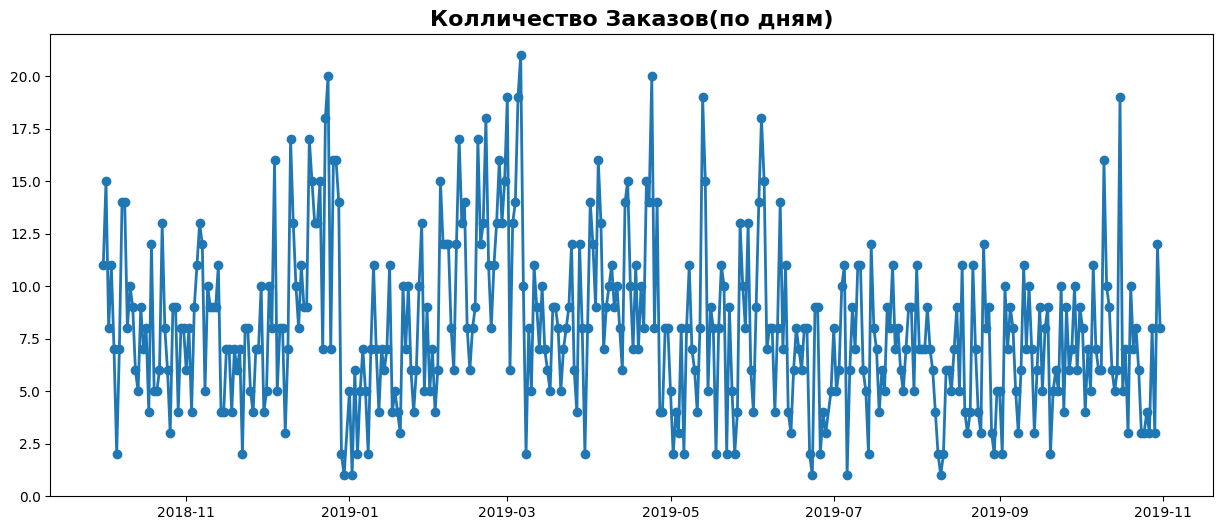

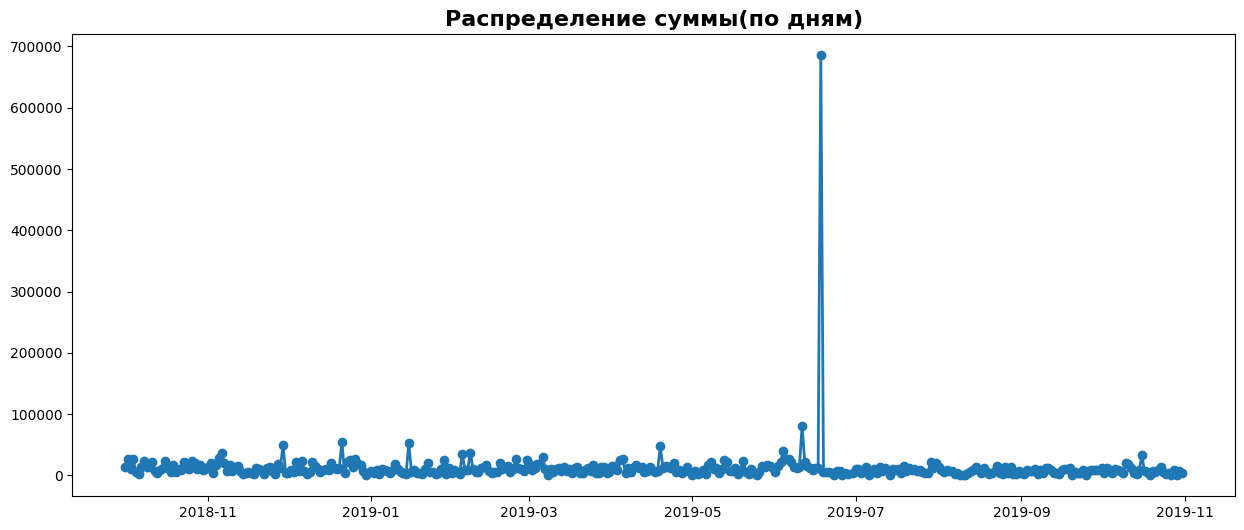

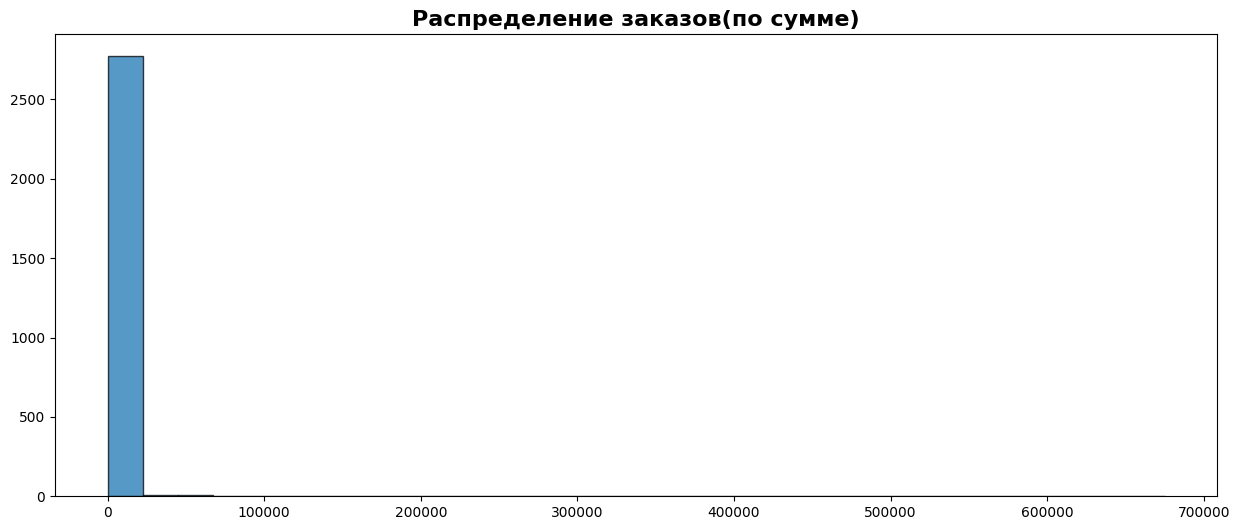

In [3]:
#Шаг 3. Исследовательский анализ данных
#Построить диаграмму количества покупок по дням

#(Распределяем по датам)
# Задаём переменную sf для удабства и группируем стобцы по датам
sf = ['Ежедневные покупки']
sf = df.groupby('date').agg({
    'order_id':'nunique',
    'revenue':'sum',
    'customer_id':'nunique'
}).reset_index()
sf.columns =['date','order_count','total_revenue','unice_customers']
sf = sf.sort_values('date')

#Построить диаграмму количества покупок по дням
# Выстраиваем фигуру (figure) с размерами 15 и 6. Используем plot для построения
# линейной диагрмаммы по дате и заказам
plt.figure(figsize=(15,6))
plt.plot(sf['date'], sf['order_count'],
         marker = 'o', linewidth = 2, markersize = 6)
plt.title('Колличество Заказов(по дням)', fontsize = 16, fontweight = 'bold' )
#В итоге выстроили график заказов по дня исползуя точки ('o') и соединяя их

#Построить диаграмму, отображающую сумму покупок по дням
# Делаем то же самое что и в предыдущем пункте, только подставляя нужное
# значение дохода
plt.figure(figsize=(15,6))
plt.plot(sf['date'], sf['total_revenue'],
         marker = 'o', linewidth = 2, markersize = 6)
plt.title('Распределение суммы(по дням)', fontsize = 16, fontweight = 'bold' )
# Получили диаграмму отображающую сумму (total_reveue) заказов по дате

#Построить гистограмму, отображающую распределение заказов по сумме
# Группируем сумму, количество, и товары по заказам (order)
sf = ['Все заказы']
sf = df.groupby('order_id').agg({
    'revenue': 'sum',
    'quantity':'sum',
    'product':'count'
}).reset_index()
sf.columns = ['order_id','order_total','total_items','unique_product']
#Задаем размеры гистограммы
plt.figure(figsize=(15,6))
plt.hist(sf['order_total'], bins = 30, edgecolor  = 'black', alpha =0.75)
#Задаём название гистограммы
plt.title('Распределение заказов(по сумме)', fontsize = 16, fontweight = 'bold')
#Итого получилось вытроить чёткие графики отображающие нужные нам запросы

In [4]:
#Шаг 4
# На основании наименования товара и данных
# открытых внешних источников предложить 3-10 категорий товаров;
# В каждой категории распределить товары на основной и дополнительный
#  ассортимент
#Разюиваем продукты по категориям и присваиваем для каждой категории
#наименования ( слова ) подходящие для конкретной категории
df['category'] = df['product'].apply(lambda x:
    'Хоз. товары и хранение' if any(w in str(x).lower() for w in ['корзина',
        'ящик', 'контейнер', 'короб', 'стеллаж', 'полка',
        'органайзер', 'вешалка', 'крючок', 'сумка', 'тележка', 'чемодан',
        'кофр', 'чехол', 'пакет', 'мешок', 'ведро', 'таз', 'корыто',
        'поддон', 'лоток', 'шкаф', 'тумба', 'комод']) else
    'Растения' if any(w in str(x).lower() for w in ['растение', 'герань',
        'пеларгония', 'цветок', 'роза', 'хризантема',
        'фиалка', 'бегония', 'суккулент', 'эвкалипт', 'каланхое', 'мирт',
        'лавр', 'мелисса', 'тимьян', 'розмарин', 'базилик', 'душица',
        'шалфей', 'кофе арабика', 'азалия', 'кампанула', 'глоксиния',
        'антуриум', 'гортензия', 'папоротник', 'цикламен', 'калатея',
        'адениум', 'фикус', 'орхидея', 'сансевиерия', 'крассула',
        'декабрист', 'пальма', 'хлорофитум', 'гибискус', 'пахира']) else
    'Посуда и кухня' if any(w in str(x).lower() for w in ['тарелка',
        'сковорода', 'кастрюля', 'чайник', 'нож', 'вилка',
        'ложка', 'кружка', 'стакан', 'кувшин', 'салатник', 'кастрюля',
        'противень', 'сковородка', 'крышка', 'половник', 'терка', 'овощечистка',
        'сковородник', 'разделочная доска', 'миска', 'блюдо', 'сервиз',
        'набор посуды', 'ковш', 'дуршлаг', 'сито', 'пресс для чеснока',
        'точилка для ножей', 'сковорода вок']) else
    'Туалет и Кухня' if any(w in str(x).lower() for w in ['ванна', 'душ',
        'туалет', 'ёрш', 'сиденье', 'коврик', 'занавеска',
        'шторка', 'полотенце', 'мыльница', 'держатель', 'зубная щетка',
        'стаканчик', 'ванночка', 'крючок', 'вешалка', 'аксессуар', 'зеркало',
        'фен', 'бритва', 'пилка', 'мочалка', 'скраб', 'гель', 'шампунь',
        'мыло', 'жидкое мыло', 'пена для ванн']) else
     'Декор и искусственные растения' if any(w in str(x).lower() for w in [
        'муляж',
        'искусственный', 'декоративный', 'букет', 'ваза', 'подсвечник',
        'картина', 'панно', 'зеркало', 'фоторамка', 'статуэтка', 'свеча',
        'аромалампа', 'гирлянда', 'новогодний', 'праздничный', 'украшение',
        'интерьерный', 'постер', 'гобелен', 'ковер', 'палас', 'дорожка']) else
      'Инструменты и креп.' if any(w in str(x).lower() for w in [ 'инструмент',
        'отвертка', 'молоток', 'пила', 'дрель', 'шуруповерт',
        'ключ', 'плоскогубцы', 'кусачки', 'ножницы', 'резак', 'лезвие',
        'сверло', 'бита', 'насадка', 'рулетка', 'уровень', 'угольник',
        'стремянка', 'лестница', 'кронштейн', 'крючок', 'петля', 'шуруп',
        'саморез', 'гвоздь', 'анкер', 'дюбель', 'скоба', 'замок', 'защелка',
        'ручка', 'планка', 'уголок', 'профиль'
    ]) else
      'Сад и огород' if any(w in str(x).lower() for w in['сад', 'огород',
        'рассада', 'семена', 'луковица', 'клубень',
        'черенок', 'горшок', 'кашпо', 'лопата', 'грабли', 'тяпка',
        'лейка', 'опрыскиватель', 'секатор', 'перчатки садовые',
        'удобрение', 'грунт', 'земля', 'почва', 'мульча', 'компост',
        'тепличка', 'парник', 'шпалера', 'опора', 'бордюр', 'саженец']) else
      'Текстиль' if any(w in str(x).lower() for w in [  'скатерть', 'салфетка',
        'подушка', 'одеяло', 'плед', 'наматрасник',
        'простыня', 'пододеяльник', 'наволочка', 'покрывало', 'гардина',
        'тюль', 'портьера', 'коврик', 'дорожка', 'полотенце', 'махровое',
        'флисовое', 'хлопковое', 'льняное', 'шелковое', 'бархатное']) else
      'Химия и уборка' if any(w in str(x) for w in ['средство', 'чистящее',
        'моющее', 'порошок', 'гель', 'жидкость',
        'спрей', 'антижир', 'отбеливатель', 'кондиционер', 'освежитель',
        'дезинфектор', 'антистатик', 'пятновыводитель', 'смягчитель',
        'очиститель', 'смывка', 'растворитель', 'клей', 'герметик',
        'шпатлевка', 'краска', 'лак', 'пропитка', 'антисептик']) else
      'прочее'
)
#После присваивания слов(ключей), создаём группу по товарам, выручке и
#по продажам и выводим это на экран.
summary = df.groupby('category').agg(
    товаров=('product', 'nunique'),
    выручка=('revenue', 'sum'),
    продажи=('quantity', 'sum')
).sort_values('выручка', ascending=False)

print("СВОДКА ПО КАТЕГОРИЯМ:")
print(summary)

# Основной/дополнительный
# Разделяем товары на основной и дополнительный
# В качестве отновного берём топ 10 товаров по доходу.И выводим их на экран.
print("\nРАЗДЕЛЕНИЕ АССОРТИМЕНТА:")
for cat in summary.index:
    cat_items = df[df['category'] == cat]
    top10 = cat_items.groupby('product')['revenue'].sum().nlargest(10)
    print(f"\n{cat.upper()}:")
    print(f"  Основной: {len(top10)} товаров")
    print(f"  Дополнительный: {cat_items['product'].nunique() - len(top10)} товаров")
    print(f"  Пример основного: {top10.index[0][:30]}...")
#Итого имеется чёткое представление о колличестве продаваемых товаров о доходе
# в каждой категории, и представление о самых доходных позициях в каждой
#категории.

СВОДКА ПО КАТЕГОРИЯМ:
                                товаров    выручка  продажи
category                                                   
прочее                              917  2223990.0     5765
Хоз. товары и хранение              341  1256513.0     2041
Растения                            356   343765.0     2824
Сад и огород                        220   231303.0     1727
Туалет и Кухня                      125   214495.0      792
Посуда и кухня                      182   180497.0     1021
Инструменты и креп.                  60   148275.0      522
Текстиль                             53   134374.0      269
Декор и искусственные растения       84   111655.0     1879
Химия и уборка                        5     6413.0       13

РАЗДЕЛЕНИЕ АССОРТИМЕНТА:

ПРОЧЕЕ:
  Основной: 10 товаров
  Дополнительный: 907 товаров
  Пример основного: Вантуз с деревянной ручкой d14...

ХОЗ. ТОВАРЫ И ХРАНЕНИЕ:
  Основной: 10 товаров
  Дополнительный: 331 товаров
  Пример основного: Сумка-тележка 2-х 

In [5]:
# Сохраняем обработанные данные для загрузки в DataLens
df.to_csv('product_assortment_analysis.csv', index=False)
print("Файл сохранен! Размер:", df.shape)
print("Колонки:", list(df.columns))

Файл сохранен! Размер: (6737, 11)
Колонки: ['date', 'customer_id', 'order_id', 'product', 'quantity', 'price', 'df_of_week', 'month', 'year', 'revenue', 'category']


#Итоговые выводы и рекомендации
##Ассортиментная матрица:

Ядро ассортимента магазина составляют категории «Хоз. товары и хранение» и «Растения». Именно на них следует делать основной упор при закупках и маркетинге.

Категории «Посуда», «Текстиль», «Инструменты» и «Декор» выполняют функцию дополняющего ассортимента. Их задача — увеличивать средний чек и удовлетворять сопутствующий спрос.

##Товарные рекомендации для прикассовой зоны (Дополнительный ассортимент):

На основе анализа в прикассовой зоне или рядом с основными товарами целесообразно размещать:

Небольшие товары из категории «Растения»: мини-горшки, семена, небольшие инструменты.

Мелкую «Декор» и «Посуду»: свечи, магниты, салфетки.

Товары из «Химия и уборка»: небольшие чистящие средства, губки.

Расходные материалы: удобрения, грунт, садовые перчатки.

##Необходимость дальнейших действий:

Категория «прочее» требует немедленной реклассификации. Её товары необходимо распределить по другим категориям, так как она искусственно занимает первое место по выручке и содержит наибольшее количество наименований. Без этого шага анализ ассортимента будет неполным.

##Практическая ценность:

Полученные результаты позволяют оптимизировать складские запасы (товары из основного ассортимента должны быть в приоритете), разработать эффективную систему перекрестных продаж и грамотно организовать торговое пространство, отделив товары для прикассовой зоны от основных стеллажей.